In [1]:
import warnings
from typing import *

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm

from analysis.utils.build_dataset import create_dataset
from core.feature_type import FeatureType
from feature_writer.FeatureWriter import REGRESSOR_OFFSETS

warnings.filterwarnings("ignore", category=RuntimeWarning)

In [2]:
# Load data from pumps/cross_sections
df: pd.DataFrame = create_dataset()
df["is_pumped"] = df["currency_pair"] == df["pumped_currency_pair"]  # create bool column is_pumped

Building dataset: 100%|██████████| 498/498 [00:05<00:00, 95.87it/s] 
2026-03-09 15:40:17,144 | WARNING | root | No data present for 25 pumps


In [3]:
df.shape

(93058, 91)

<h4>Look at the data</h4>

<p>We see that over time the overall cross-section size grows. Meaning it is more difficult to correctly predict which asset will be manipulated</p>

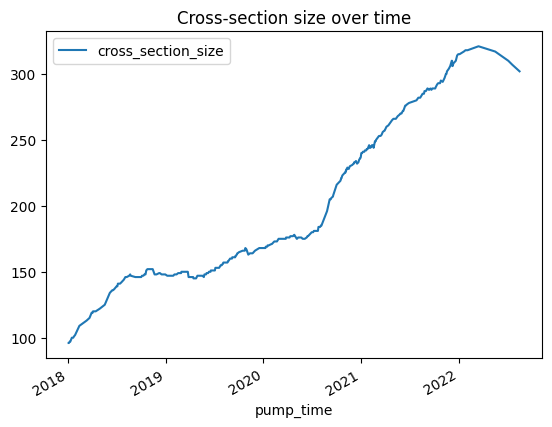

In [4]:
# cross-section statistics
(
    df.groupby("pump_hash")
    .agg(
        pump_time=("pump_time", "first"),
        cross_section_size=("pump_time", "count")
    )
    .sort_values(by="pump_time", ascending=True)
    .plot(x="pump_time", y="cross_section_size", title="Cross-section size over time")
)
plt.show()

<h4>Feature distributions and cross-sectional standardisation</h4>

<p>Now we will go through each FeatureType and display distribution stats and fix gaps in data</p>

<h4>Powerlaw features</h4>

In [5]:
powerlaw_cols: List[str] = FeatureType.POWERLAW_ALPHA.col_names(offsets=REGRESSOR_OFFSETS)
df[powerlaw_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
powerlaw_alpha@5MIN,83176.0,inf,NaN,-9.007199e+15,1.288491,1.425135,1.814165,inf
powerlaw_alpha@15MIN,90389.0,inf,NaN,-9.007199e+15,1.240540,1.324877,1.464839,inf
powerlaw_alpha@1H,92178.0,inf,NaN,1.086600e+00,1.199427,1.255902,1.332283,inf
powerlaw_alpha@2H,92223.0,inf,NaN,1.083316e+00,1.183039,1.231946,1.296669,inf
powerlaw_alpha@4H,92237.0,inf,NaN,1.085578e+00,1.168668,1.212866,1.267098,inf
powerlaw_alpha@12H,92258.0,1.204164,0.079963,1.085860e+00,1.153775,1.191352,1.234870,4.958618
powerlaw_alpha@1D,92261.0,1.191985,0.069083,1.084541e+00,1.147324,1.180051,1.220419,4.713602
powerlaw_alpha@2D,92310.0,1.181707,0.061434,1.042519e+00,1.141751,1.170982,1.208314,4.552822
powerlaw_alpha@7D,92485.0,1.168375,0.048692,1.041700e+00,1.134230,1.159121,1.192987,2.326308
powerlaw_alpha@14D,92661.0,1.162844,0.044515,1.041700e+00,1.130775,1.154292,1.186518,2.035152


In [6]:
# clip pawerlaw features to range [1, 2]
df[powerlaw_cols] = df[powerlaw_cols].clip(1, 2)
df[powerlaw_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
powerlaw_alpha@5MIN,83176.0,1.532030,0.295659,1.000000,1.288491,1.425135,1.814165,2.0
powerlaw_alpha@15MIN,90389.0,1.398784,0.233052,1.000000,1.240540,1.324877,1.464839,2.0
powerlaw_alpha@1H,92178.0,1.283299,0.132082,1.086600,1.199427,1.255902,1.332283,2.0
powerlaw_alpha@2H,92223.0,1.251300,0.103687,1.083316,1.183039,1.231946,1.296669,2.0
powerlaw_alpha@4H,92237.0,1.228279,0.088869,1.085578,1.168668,1.212866,1.267098,2.0
powerlaw_alpha@12H,92258.0,1.203897,0.074788,1.085860,1.153775,1.191352,1.234870,2.0
powerlaw_alpha@1D,92261.0,1.191867,0.066480,1.084541,1.147324,1.180051,1.220419,2.0
powerlaw_alpha@2D,92310.0,1.181601,0.058761,1.042519,1.141751,1.170982,1.208314,2.0
powerlaw_alpha@7D,92485.0,1.168367,0.048532,1.041700,1.134230,1.159121,1.192987,2.0
powerlaw_alpha@14D,92661.0,1.162843,0.044501,1.041700,1.130775,1.154292,1.186518,2.0


In [7]:
df[powerlaw_cols].isna().sum()

powerlaw_alpha@5MIN     9882
powerlaw_alpha@15MIN    2669
powerlaw_alpha@1H        880
powerlaw_alpha@2H        835
powerlaw_alpha@4H        821
powerlaw_alpha@12H       800
powerlaw_alpha@1D        797
powerlaw_alpha@2D        748
powerlaw_alpha@7D        573
powerlaw_alpha@14D       397
dtype: int64

In [8]:
df[powerlaw_cols] = df[powerlaw_cols].fillna(-1)

<h4>Asset return features</h4>

<p><b>Note: returns are measured in pips</b></p>
<p>Here we observe that anticipated behaviour as time window grows the min/max and std become higher in absolute terms</p>

In [9]:
asset_return_cols: List[str] = FeatureType.ASSET_RETURN.col_names(offsets=REGRESSOR_OFFSETS)
df[asset_return_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
asset_return@5MIN,83175.0,3.539846,141.873713,-3333.333333,-19.080660,0.000000,20.686089,7000.000000
asset_return@15MIN,90388.0,5.120693,167.075719,-3333.333333,-31.156481,0.000000,34.603323,7000.000000
asset_return@1H,92176.0,7.406318,232.136653,-5410.958904,-65.703022,0.000000,64.102564,7288.135593
asset_return@2H,92216.0,8.067106,289.355256,-5000.000000,-96.339114,0.000000,83.333333,12371.541502
asset_return@4H,92222.0,21.139167,367.223518,-3875.968992,-126.756781,0.000000,123.456790,12549.800797
asset_return@12H,92200.0,35.268086,677.846154,-6392.125806,-211.267606,0.000000,203.488372,119032.258065
asset_return@1D,92185.0,31.192420,875.744848,-4814.814815,-334.316618,-27.855153,269.662921,119032.258065
asset_return@2D,92152.0,2.318001,1221.421779,-6050.000000,-508.474576,-79.630507,327.584269,119032.258065


In [10]:
df[asset_return_cols].isna().sum()

asset_return@5MIN     9883
asset_return@15MIN    2670
asset_return@1H        882
asset_return@2H        842
asset_return@4H        836
asset_return@12H       858
asset_return@1D        873
asset_return@2D        906
asset_return@7D       1500
asset_return@14D      2161
dtype: int64

<h4>Asset return zscores</h4>

In [11]:
asset_return_zscore_cols: List[str] = FeatureType.ASSET_RETURN_ZSCORE.col_names(offsets=REGRESSOR_OFFSETS)
df[asset_return_zscore_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
asset_return_zscore@1H,92208.0,0.061172,1.014406,-14.091035,-0.384391,0.000000,0.397763,20.413539
asset_return_zscore@2H,92232.0,0.042986,0.735699,-7.602639,-0.301473,0.000000,0.301271,13.955420
asset_return_zscore@4H,92237.0,0.039590,0.542854,-6.030088,-0.220408,0.000749,0.229091,13.955420
asset_return_zscore@12H,92257.0,0.023507,0.301506,-2.251391,-0.124250,0.001143,0.137532,6.795124
asset_return_zscore@1D,92260.0,0.007973,0.194694,-1.767127,-0.097526,-0.005797,0.095553,1.892111
asset_return_zscore@2D,92307.0,-0.001343,0.136194,-2.123060,-0.075191,-0.007600,0.063614,4.823023
asset_return_zscore@7D,92479.0,-0.002920,0.081349,-2.123060,-0.046178,-0.003905,0.039029,4.974488
asset_return_zscore@14D,92652.0,-0.002517,0.061542,-2.308614,-0.035145,-0.002381,0.030157,4.972071


In [12]:
df[asset_return_zscore_cols].isna().sum()

asset_return_zscore@5MIN     11853
asset_return_zscore@15MIN    11853
asset_return_zscore@1H         850
asset_return_zscore@2H         826
asset_return_zscore@4H         821
asset_return_zscore@12H        801
asset_return_zscore@1D         798
asset_return_zscore@2D         751
asset_return_zscore@7D         579
asset_return_zscore@14D        406
dtype: int64

<h4>Quote abs zscore</h4>

In [13]:
quote_abs_zscore_cols: List[str] = FeatureType.QUOTE_ABS_ZSCORE.col_names(offsets=REGRESSOR_OFFSETS)
df[quote_abs_zscore_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
quote_abs_zscore@1H,92208.0,0.119712,1.203549,-2.641997,-0.342723,-0.166038,0.128377,26.263573
quote_abs_zscore@2H,92232.0,0.102321,1.015910,-2.510568,-0.325692,-0.155033,0.134466,17.190673
quote_abs_zscore@4H,92237.0,0.086799,0.867164,-2.512795,-0.306628,-0.141730,0.134862,11.425492
quote_abs_zscore@12H,92257.0,0.017264,0.627528,-2.237507,-0.297820,-0.144083,0.094122,6.092637
quote_abs_zscore@1D,92260.0,-0.015500,0.520576,-2.144866,-0.290051,-0.143229,0.071714,4.622350
quote_abs_zscore@2D,92307.0,-0.018734,0.432933,-1.903089,-0.264354,-0.125284,0.088903,4.622350
quote_abs_zscore@7D,92479.0,-0.018442,0.275570,-1.296574,-0.197945,-0.071070,0.123966,1.901186
quote_abs_zscore@14D,92652.0,-0.016686,0.180594,-0.913495,-0.137189,-0.022492,0.101910,2.050641


<h4>Share of long trades</h4>

In [14]:
share_of_long_trades_cols: List[str] = FeatureType.SHARE_OF_LONG_TRADES.col_names(offsets=REGRESSOR_OFFSETS)
df[share_of_long_trades_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
share_of_long_trades@5MIN,83176.0,0.517268,0.292531,0.000000,0.333333,0.500000,0.714286,1.000000
share_of_long_trades@15MIN,90389.0,0.518482,0.224703,0.000000,0.388889,0.517391,0.664336,1.000000
share_of_long_trades@1H,92178.0,0.517181,0.150249,0.000000,0.433333,0.517369,0.603774,1.000000
share_of_long_trades@2H,92223.0,0.516031,0.124298,0.000000,0.447445,0.515732,0.585880,1.000000
share_of_long_trades@4H,92237.0,0.517505,0.106134,0.000000,0.460765,0.515888,0.574194,1.000000
share_of_long_trades@12H,92258.0,0.518423,0.090379,0.000000,0.473163,0.516112,0.562183,0.995282
share_of_long_trades@1D,92261.0,0.519964,0.080382,0.028927,0.481622,0.516466,0.555286,0.993056
share_of_long_trades@2D,92310.0,0.521056,0.072479,0.047204,0.487039,0.516151,0.550318,0.989017
share_of_long_trades@7D,92485.0,0.523118,0.063910,0.083655,0.494262,0.516947,0.545596,0.976714
share_of_long_trades@14D,92661.0,0.525011,0.059946,0.093449,0.497412,0.517653,0.544994,0.962848


<h4>Slippage imbalance</h4>

In [15]:
slippage_imbalance_cols: List[str] = FeatureType.SLIPPAGE_IMBALANCE.col_names(offsets=REGRESSOR_OFFSETS)
df[slippage_imbalance_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
slippage_imbalance@5MIN,51963.0,-0.045825,0.894400,-1.0,-1.000000,-0.203597,1.000000,1.0
slippage_imbalance@15MIN,71584.0,-0.062943,0.839990,-1.0,-0.992665,-0.185786,0.939368,1.0
slippage_imbalance@1H,86636.0,-0.103715,0.736776,-1.0,-0.853119,-0.201057,0.622171,1.0
slippage_imbalance@2H,89620.0,-0.119651,0.674076,-1.0,-0.757647,-0.190966,0.468534,1.0
slippage_imbalance@4H,91041.0,-0.122272,0.612953,-1.0,-0.659887,-0.173481,0.362258,1.0
slippage_imbalance@12H,91900.0,-0.126439,0.529661,-1.0,-0.532164,-0.155010,0.238582,1.0
slippage_imbalance@1D,92136.0,-0.129699,0.478849,-1.0,-0.467602,-0.152352,0.176985,1.0
slippage_imbalance@2D,92274.0,-0.129036,0.424993,-1.0,-0.402324,-0.143273,0.120882,1.0
slippage_imbalance@7D,92483.0,-0.108529,0.341115,-1.0,-0.299058,-0.119926,0.070548,1.0
slippage_imbalance@14D,92661.0,-0.098832,0.303030,-1.0,-0.259085,-0.110552,0.053645,1.0


In [16]:
df[slippage_imbalance_cols].isna().sum()

slippage_imbalance@5MIN     41095
slippage_imbalance@15MIN    21474
slippage_imbalance@1H        6422
slippage_imbalance@2H        3438
slippage_imbalance@4H        2017
slippage_imbalance@12H       1158
slippage_imbalance@1D         922
slippage_imbalance@2D         784
slippage_imbalance@7D         575
slippage_imbalance@14D        397
dtype: int64

<h4>Flow imbalance</h4>

In [17]:
flow_imbalance_cols: List[str] = FeatureType.FLOW_IMBALANCE.col_names(offsets=REGRESSOR_OFFSETS)
df[flow_imbalance_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
flow_imbalance@5MIN,83176.0,-0.013414,0.704083,-1.000000,-0.680634,-0.020261,0.644717,1.000000
flow_imbalance@15MIN,90389.0,-0.029935,0.581917,-1.000000,-0.482985,-0.031532,0.405582,1.000000
flow_imbalance@1H,92178.0,-0.045771,0.412345,-1.000000,-0.308347,-0.042699,0.207564,1.000000
flow_imbalance@2H,92223.0,-0.051732,0.334519,-1.000000,-0.248145,-0.045282,0.140321,1.000000
flow_imbalance@4H,92237.0,-0.046012,0.270830,-1.000000,-0.194336,-0.039754,0.100278,1.000000
flow_imbalance@12H,92258.0,-0.039562,0.201699,-1.000000,-0.143222,-0.037455,0.059132,0.993480
flow_imbalance@1D,92261.0,-0.034394,0.165865,-0.976580,-0.117182,-0.035160,0.039474,0.984582
flow_imbalance@2D,92310.0,-0.031868,0.138630,-0.976174,-0.100197,-0.035564,0.024604,0.967960
flow_imbalance@7D,92485.0,-0.023573,0.107280,-0.958871,-0.076927,-0.031297,0.012470,0.932742
flow_imbalance@14D,92661.0,-0.018755,0.096815,-0.895483,-0.068022,-0.028284,0.010833,0.907893


<h4>Num trades</h4>

In [18]:
num_trades_cols: List[str] = FeatureType.NUM_TRADES.col_names(offsets=REGRESSOR_OFFSETS)
df[num_trades_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
num_trades@5MIN,93058.0,32.071095,100.742905,0.0,2.00,8.0,25.00,4987.0
num_trades@15MIN,93058.0,95.573438,276.445506,0.0,9.00,27.0,76.00,12184.0
num_trades@1H,93058.0,394.664371,1065.040030,0.0,47.00,123.0,329.00,33566.0
num_trades@2H,93058.0,784.471985,2105.716726,0.0,101.00,252.5,666.00,88326.0
num_trades@4H,93058.0,1545.553311,4027.136423,0.0,213.00,517.0,1343.00,137259.0
num_trades@12H,93058.0,4307.020514,10927.010818,0.0,636.00,1521.0,3820.75,437471.0
num_trades@1D,93058.0,8453.650895,21268.812450,0.0,1310.00,3057.5,7539.75,855882.0
num_trades@2D,93058.0,16945.006125,41277.808049,0.0,2801.00,6380.0,15310.75,1302688.0
num_trades@7D,93058.0,59441.423789,135038.076218,0.0,11312.00,24301.5,55265.00,3823480.0
num_trades@14D,93058.0,117484.724774,256322.602715,0.0,24269.25,50084.5,111708.75,6704862.0


In [19]:
# overall NaNs
df[df.isna().any(axis=1)].shape

(55595, 91)

<h4>Plot feature distributions before and after cross-sectional standardisation</h4>

$$X_{\text{std}} = \frac{X - \bar{X}}{\sigma_{X}}$$

In [20]:
# plot feature distributions before cross-sectional standardisation
cols_to_scale: List[str] = asset_return_cols + asset_return_zscore_cols + quote_abs_zscore_cols + powerlaw_cols

dfs: List[pd.DataFrame] = []

for i, (pump_hash, df_cross_section) in tqdm(enumerate(df.groupby("pump_hash"))):
    df_cross_section = df_cross_section.reset_index(drop=True)
    # Apply cross-sectional standardisation
    for col in cols_to_scale:
        df_cross_section[col] = (df_cross_section[col] - df_cross_section[col].mean()) / df_cross_section[col].std()
    df_cross_section["pump_id"] = i
    dfs.append(df_cross_section)

df_scaled: pd.DataFrame = pd.concat(dfs)
df_scaled = df_scaled.reset_index(drop=True)
df_scaled.head(2)

473it [00:03, 123.48it/s]


,asset_return@5MIN,asset_return_zscore@5MIN,quote_abs_zscore@5MIN,share_of_long_trades@5MIN,powerlaw_alpha@5MIN,slippage_imbalance@5MIN,flow_imbalance@5MIN,num_trades@5MIN,asset_return@15MIN,asset_return_zscore@15MIN,...,target_return@2MIN,target_return@3MIN,target_return@4MIN,target_return@5MIN,currency_pair,pump_hash,pump_time,pumped_currency_pair,is_pumped,pump_id
0,-0.444505,0.262494,-0.011331,0.00,0.786943,-1.0,-1.000000,12,-0.261520,0.262494,...,92.02454,92.02454,97.137014,97.137014,ACM-BTC,ACM-BTC:BINANCE_SPOT:2021-06-05T18-00-13,2021-06-05 18:00:13,ACM-BTC,True,0
1,1.452517,-0.231829,-0.369049,0.75,0.260517,1.0,0.967997,4,0.095459,-0.231829,...,NaN,NaN,0.000000,-41.666667,TLM-BTC,ACM-BTC:BINANCE_SPOT:2021-06-05T18-00-13,2021-06-05 18:00:13,ACM-BTC,False,0


3it [00:00,  3.22it/s]


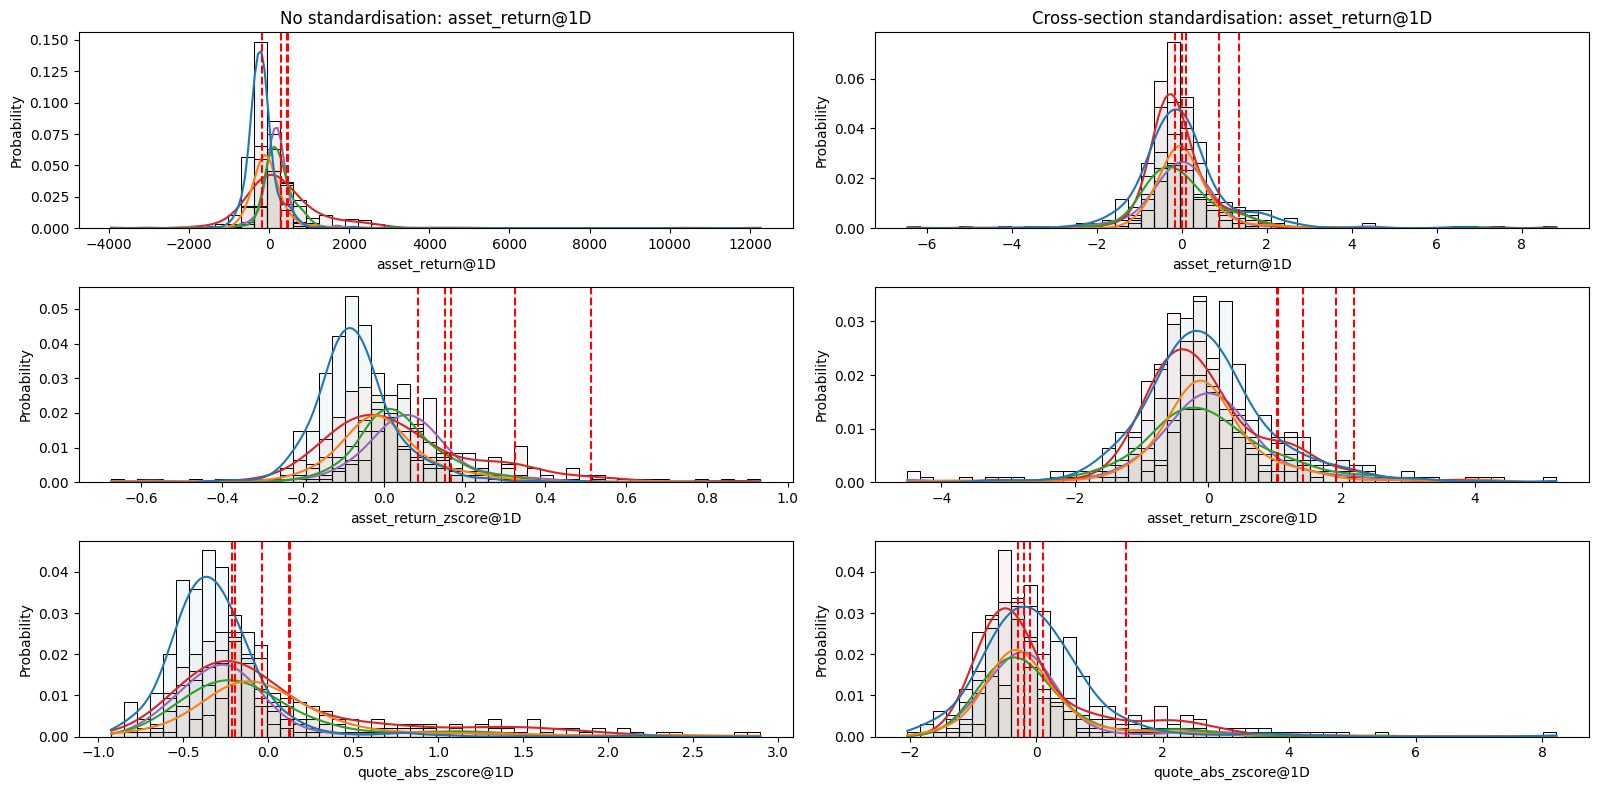

In [21]:
from core.time_utils import NamedTimeDelta
import seaborn as sns

groups_to_plot: List[FeatureType] = [
    FeatureType.ASSET_RETURN,
    FeatureType.ASSET_RETURN_ZSCORE,
    FeatureType.QUOTE_ABS_ZSCORE,
]

use_offset: NamedTimeDelta = NamedTimeDelta.ONE_DAY  # -> we will be plotting features from groups_to_plot at ONE_DAY offset
fig, axs = plt.subplots(len(groups_to_plot), 2, figsize=(16, 8))

# create two smaller dataframes with fewer cross-sections to plot
selected_pump_hashes: np.array = np.random.choice(
    df["pump_hash"].unique(), 5, replace=False
)  # use 5 pumps for plotting

_df_small: pd.DataFrame = df[df["pump_hash"].isin(selected_pump_hashes)]
_df_scaled_small: pd.DataFrame = df_scaled[df_scaled["pump_hash"].isin(selected_pump_hashes)]

feature: FeatureType
i = 0

for (ax1, ax2), feature in tqdm(zip(axs, groups_to_plot)):
    col_name: str = feature.col_name(offset=use_offset)
    # Plot pumps without standardisation
    sns.histplot(
        data=_df_small,
        x=col_name,
        hue="pump_hash",
        ax=ax1, legend=False, alpha=0.05, bins=50, kde=True, stat="probability"
    )
    if i == 0:
        ax1.set_title(f"No standardisation: {col_name}")
    for pump_hash in selected_pump_hashes:
        ax1.axvline(
            x=_df_small.loc[_df_small["is_pumped"] & (_df_small["pump_hash"] == pump_hash), col_name].iloc[0],
            color="red", linestyle="--"
        )

    sns.histplot(
        data=_df_scaled_small,
        x=col_name,
        hue="pump_hash",
        ax=ax2, legend=False, alpha=0.05, bins=50, kde=True, stat="probability"
    )
    if i == 0:
        ax2.set_title(f"Cross-section standardisation: {col_name}")
    for pump_hash in selected_pump_hashes:
        ax2.axvline(
            x=_df_scaled_small.loc[
                _df_scaled_small["is_pumped"] & (_df_scaled_small["pump_hash"] == pump_hash), col_name
            ].iloc[0],
            color="red", linestyle="--"
        )
    i+=1

plt.tight_layout()
plt.savefig("images/cs_standartization_impact.png")

<h4>Split data and train the first model</h4>

In [22]:
from analysis.utils.sample import Sample
from analysis.utils.feature_set import FeatureSet
from analysis.utils.experiment import Experiment

# use manually predefined set of features if we want to add more features we need to make sure to add them to FeatureSet.auto()
# FeatureSet defines the numeric/categorical regressors and target used for training, it is better to have this object passed around instead of multiple sets of features
# that's why we have it
feature_set: FeatureSet = FeatureSet.auto()

<h4>LogisticRegression model</h4>

In [23]:
from analysis.pipelines.LogisticRegression.pipe import LogisticRegressionPipeline
from analysis.pipelines.LogisticRegression.model import LogisticRegressionModel


pipe = LogisticRegressionPipeline()
sample = pipe.create_sample()

2026-03-09 15:40:24,167 | INFO | root | Building dataset and preprocessing data
2026-03-09 15:40:24,167 | INFO | root | Building raw dataset from feature files
Building dataset: 100%|██████████| 498/498 [00:04<00:00, 100.78it/s]
2026-03-09 15:40:29,676 | WARNING | root | No data present for 25 pumps
2026-03-09 15:40:29,726 | INFO | root | Removing failed pump cross sections
2026-03-09 15:40:29,768 | WARNING | root | Removed 114 failed pumps
2026-03-09 15:40:30,162 | INFO | root | Nans
quote_abs_zscore@5MIN      0
quote_abs_zscore@15MIN     0
quote_abs_zscore@1H        0
quote_abs_zscore@2H        0
quote_abs_zscore@4H        0
                          ..
asset_return_zscore@1D     0
asset_return_zscore@2D     0
asset_return_zscore@7D     0
asset_return_zscore@14D    0
num_prev_pump              0
Length: 81, dtype: int64
2026-03-09 15:40:30,492 | INFO | root | Dataset DatasetType.TRAIN. Shape (35121, 92)
2026-03-09 15:40:30,493 | INFO | root | Dataset DatasetType.VALIDATION. Shape (17

In [24]:
model: LogisticRegressionModel = pipe.train(sample=sample, tuned=False)
experiment_lr = Experiment(experiment_name="LogisticRegression", model=model, sample=sample)

2026-03-09 15:40:30,529 | INFO | root | Training model
/home/borokoko/.cache/pypoetry/virtualenvs/pumps-and-dumps-tlIXlxVv-py3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


In [25]:
model: LogisticRegressionModel = pipe.train(sample=sample, tuned=True)
experiment_lr_tuned = Experiment(experiment_name="LogisticRegression + Tuned", model=model, sample=sample)

2026-03-09 15:40:31,946 | INFO | root | Training model
/home/borokoko/.cache/pypoetry/virtualenvs/pumps-and-dumps-tlIXlxVv-py3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


<h4>RandomForestClassifier</h4>

In [26]:
from analysis.pipelines.RandomForest.pipe import RandomForestPipeline
from analysis.pipelines.RandomForest.model import RandomForestModel


pipe = RandomForestPipeline()
sample: Sample = pipe.create_sample()

2026-03-09 15:40:34,303 | INFO | root | Building dataset and preprocessing data
2026-03-09 15:40:34,303 | INFO | root | Using cached raw dataset
2026-03-09 15:40:34,340 | INFO | root | Removing failed pump cross sections
2026-03-09 15:40:34,382 | WARNING | root | Removed 114 failed pumps
2026-03-09 15:40:34,704 | INFO | root | Dataset DatasetType.TRAIN. Shape (35121, 92)
2026-03-09 15:40:34,705 | INFO | root | Dataset DatasetType.VALIDATION. Shape (17479, 92)
2026-03-09 15:40:34,705 | INFO | root | Dataset DatasetType.TEST. Shape (16960, 92)


In [27]:
model: RandomForestModel = pipe.train(sample, tuned=False)
experiment_rf = Experiment(experiment_name="RandomForestClassifier", model=model, sample=sample)

2026-03-09 15:40:34,744 | INFO | root | Training model


In [28]:
model: RandomForestModel = pipe.train(sample, tuned=True)
experiment_rf_tuned = Experiment(experiment_name="RandomForestClassifier + Tuned", model=model, sample=sample)

2026-03-09 15:40:36,245 | INFO | root | Training model


<h4>TOP-K or Hit ratio</h4>

<p>This metric measures the change of getting the only positive given we take K highest logits</p>

In [29]:
from analysis.utils.metrics import calculate_topk

?calculate_topk

Signature:
calculate_topk(
    model: analysis.pipelines.BaseModel.ImplementsRank,
    dataset: analysis.utils.sample.Dataset,
    bins: Iterable[float],
) -> pandas.Series
Docstring:
:param bins: bins used to calculate topk
:return: pd.Series with topk values. Which measures the chance of predicting the actual pump given we take a portfolio
of size K
File:      ~/dev/pumps_and_dumps/src/analysis/utils/metrics.py
Type:      function

<h4>TOP-K%</h4>

In [30]:
from analysis.utils.metrics import calculate_topk_percent

?calculate_topk

Signature:
calculate_topk(
    model: analysis.pipelines.BaseModel.ImplementsRank,
    dataset: analysis.utils.sample.Dataset,
    bins: Iterable[float],
) -> pandas.Series
Docstring:
:param bins: bins used to calculate topk
:return: pd.Series with topk values. Which measures the chance of predicting the actual pump given we take a portfolio
of size K
File:      ~/dev/pumps_and_dumps/src/analysis/utils/metrics.py
Type:      function

<h4>TOP-K% AUC</h4>

In [31]:
from analysis.utils.metrics import calculate_topk_percent_auc

?calculate_topk_percent_auc

Signature:
calculate_topk_percent_auc(
    model: analysis.pipelines.BaseModel.ImplementsRank,
    dataset: analysis.utils.sample.Dataset,
) -> float
Docstring:
:return: If we iterate over all percentages from (0, 1) and compute TOPK% accuracy for each, we can measure overall
performance using AUC approach
File:      ~/dev/pumps_and_dumps/src/analysis/utils/metrics.py
Type:      function

<h4>TopKPortfolio</h4>

In [32]:
from analysis.portfolio.TOPKPortfolio import TOPKPortfolio
from analysis.portfolio.BasePortfolio import PortfolioStats
from core.pump_event import PumpEvent
from core.currency_pair import CurrencyPair
from core.exchange import Exchange
from datetime import datetime

pump: PumpEvent = PumpEvent(
    currency_pair=CurrencyPair.from_string("ACM-BTC"),
    time=datetime.strptime("2021-06-05 18:00:13", "%Y-%m-%d %H:%M:%S"),
    exchange=Exchange.BINANCE_SPOT
)

manager = TOPKPortfolio(model=model, portfolio_size=5)

In [33]:
?manager.evaluate_for_pump

Signature:
manager.evaluate_for_pump(
    dataset: analysis.utils.sample.Dataset,
    pump: core.pump_event.PumpEvent,
) -> analysis.portfolio.BasePortfolio.PortfolioStats
Docstring:
:params cross_section: a cross-section dataframe containing all features needed for model to make predictions
:params pump: pump event of the current cross-section
:returns: return of the portfolio selected by the model and corresponding portfolio
File:      ~/dev/pumps_and_dumps/src/analysis/portfolio/BasePortfolio.py
Type:      method

In [34]:
from analysis.utils.sample import DatasetType, Dataset

dataset: Dataset = sample.get_dataset(ds_type=DatasetType.TEST)
stats: List[PortfolioStats] = []

for pump in tqdm(dataset.get_pumps()):
    stats.append(
        manager.evaluate_for_pump(dataset=dataset, pump=pump)
    )

100%|██████████| 58/58 [00:41<00:00,  1.41it/s]


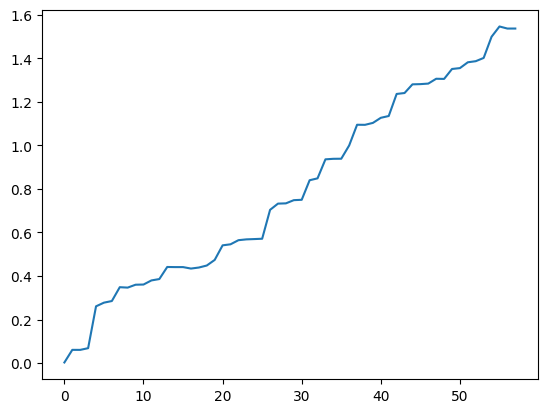

In [35]:
pnls = [stat.pnl for stat in stats]

plt.plot(np.array(pnls).cumsum())

<h4>CatboostClassifier</h4>

In [36]:
from analysis.pipelines.CatboostClassifier.pipe import CatboostClassifierPipeline
from analysis.pipelines.CatboostClassifier.model import CatboostClassifierModel


pipe = CatboostClassifierPipeline()
sample: Sample = pipe.create_sample()

2026-03-09 15:41:36,187 | INFO | root | Building dataset and preprocessing data
2026-03-09 15:41:36,188 | INFO | root | Using cached raw dataset
2026-03-09 15:41:36,221 | INFO | root | Removing failed pump cross sections
2026-03-09 15:41:36,269 | WARNING | root | Removed 114 failed pumps
2026-03-09 15:41:36,618 | INFO | root | Dataset DatasetType.TRAIN. Shape (35121, 92)
2026-03-09 15:41:36,619 | INFO | root | Dataset DatasetType.VALIDATION. Shape (17479, 92)
2026-03-09 15:41:36,619 | INFO | root | Dataset DatasetType.TEST. Shape (16960, 92)


In [37]:
sample.get_dataset(ds_type=DatasetType.TEST).all_data().groupby("pump_hash")["pump_hash"].count().mean()

np.float64(292.41379310344826)

In [38]:
model: CatboostClassifierModel = pipe.train(sample, tuned=False)
experiment_cb = Experiment(experiment_name="CatboostClassifier", model=model, sample=sample)

In [39]:
model: CatboostClassifierModel = pipe.train(sample, tuned=True)
experiment_cb_tuned = Experiment(experiment_name="CatboostClassifier + Tuned", model=model, sample=sample)

<h4>CatboostClassifier + SMOTE</h4>

In [40]:
from analysis.pipelines.CatboostClassifierSMOTE.pipe import CatboostClassifierSMOTEPipeline

pipe = CatboostClassifierSMOTEPipeline()
sample: Sample = pipe.create_sample()

2026-03-09 15:41:38,688 | INFO | root | Building dataset and preprocessing data
2026-03-09 15:41:38,689 | INFO | root | Using cached raw dataset
2026-03-09 15:41:38,724 | INFO | root | Removing failed pump cross sections
2026-03-09 15:41:38,764 | WARNING | root | Removed 114 failed pumps
2026-03-09 15:41:39,401 | INFO | root | Nans
quote_abs_zscore@5MIN      0
quote_abs_zscore@15MIN     0
quote_abs_zscore@1H        0
quote_abs_zscore@2H        0
quote_abs_zscore@4H        0
                          ..
asset_return_zscore@1D     0
asset_return_zscore@2D     0
asset_return_zscore@7D     0
asset_return_zscore@14D    0
num_prev_pump              0
Length: 81, dtype: int64
2026-03-09 15:41:39,422 | INFO | root | Dataset DatasetType.TRAIN. Shape (35121, 92)
2026-03-09 15:41:39,422 | INFO | root | Dataset DatasetType.VALIDATION. Shape (17479, 92)
2026-03-09 15:41:39,423 | INFO | root | Dataset DatasetType.TEST. Shape (16960, 92)
2026-03-09 15:41:39,459 | INFO | root | Applying SMOTE


In [41]:
model: CatboostClassifierModel = pipe.train(sample, tuned=False)
experiment_cb_smote = Experiment(experiment_name="CatboostClassifier + SMOTE", model=model, sample=sample)

In [42]:
model: CatboostClassifierModel = pipe.train(sample, tuned=True)
experiment_cb_smote_tuned = Experiment(experiment_name="CatboostClassifier + SMOTE + Tuned", model=model, sample=sample)

<h4>CatboostRanker</h4>

In [43]:
from analysis.pipelines.CatboostRanker.pipe import CatboostRankerPipeline
from analysis.pipelines.CatboostRanker.model import CatboostRankerModel

pipe = CatboostRankerPipeline()
sample: Sample = pipe.create_sample()

2026-03-09 15:42:09,647 | INFO | root | Building dataset and preprocessing data
2026-03-09 15:42:09,648 | INFO | root | Using cached raw dataset
2026-03-09 15:42:09,691 | INFO | root | Removing failed pump cross sections
2026-03-09 15:42:09,740 | WARNING | root | Removed 114 failed pumps
2026-03-09 15:42:10,068 | INFO | root | Dataset DatasetType.TRAIN. Shape (35121, 93)
2026-03-09 15:42:10,069 | INFO | root | Dataset DatasetType.VALIDATION. Shape (17479, 93)
2026-03-09 15:42:10,069 | INFO | root | Dataset DatasetType.TEST. Shape (16960, 93)


In [44]:
model: CatboostRankerModel = pipe.train(sample, tuned=False)
experiment_cb_ranker = Experiment(experiment_name="CatboostRanker", model=model, sample=sample)

In [45]:
model: CatboostRankerModel = pipe.train(sample, tuned=True)
experiment_cb_ranker_tuned = Experiment(experiment_name="CatboostRanker + Tuned", model=model, sample=sample)

2026-03-09 15:42:11,685 | INFO | root | Loading parameters from CatboostRankerPipelineStudy


<h4>CatboostClassifier + TOPKAUC Early stopping</h4>

In [46]:
from analysis.pipelines.CatboostClassifierTOPKAUC.pipe import CatboostClassifierTOPKAUCPipeline

pipe = CatboostClassifierTOPKAUCPipeline()
sample: Sample = pipe.create_sample()

2026-03-09 15:42:13,253 | INFO | root | Building dataset and preprocessing data
2026-03-09 15:42:13,253 | INFO | root | Using cached raw dataset
2026-03-09 15:42:13,292 | INFO | root | Removing failed pump cross sections
2026-03-09 15:42:13,336 | WARNING | root | Removed 114 failed pumps
2026-03-09 15:42:13,704 | INFO | root | Dataset DatasetType.TRAIN. Shape (35121, 92)
2026-03-09 15:42:13,705 | INFO | root | Dataset DatasetType.VALIDATION. Shape (17479, 92)
2026-03-09 15:42:13,705 | INFO | root | Dataset DatasetType.TEST. Shape (16960, 92)


In [47]:
model: CatboostClassifierModel = pipe.train(sample, tuned=True)
experiment_cb_topkauc_tuned = Experiment(experiment_name="CatboostClassifier + TOPKAUC Early Stopping", model=model, sample=sample)

/home/borokoko/.cache/pypoetry/virtualenvs/pumps-and-dumps-tlIXlxVv-py3.13/lib/python3.13/site-packages/catboost/core.py:2627: UserWarning: Failed to import numba for optimizing custom metrics and objectives
  _check_train_params(params)


0:	learn: 0.7553965	test: 0.8318919	best: 0.8318919 (0)	total: 113ms	remaining: 1m 52s
10:	learn: 0.8666960	test: 0.8864865	best: 0.8910135 (8)	total: 1.21s	remaining: 1m 48s
20:	learn: 0.8898238	test: 0.9014189	best: 0.9014189 (20)	total: 2.23s	remaining: 1m 44s
30:	learn: 0.9020264	test: 0.9047973	best: 0.9068243 (29)	total: 3.18s	remaining: 1m 39s
40:	learn: 0.9079736	test: 0.9060811	best: 0.9092568 (37)	total: 4.11s	remaining: 1m 36s
50:	learn: 0.9110132	test: 0.9063514	best: 0.9092568 (37)	total: 5.05s	remaining: 1m 33s
60:	learn: 0.9147137	test: 0.9086486	best: 0.9092568 (37)	total: 5.98s	remaining: 1m 32s
70:	learn: 0.9180837	test: 0.9097973	best: 0.9102703 (67)	total: 7.15s	remaining: 1m 33s
80:	learn: 0.9229956	test: 0.9102703	best: 0.9128378 (74)	total: 8.37s	remaining: 1m 35s
90:	learn: 0.9264758	test: 0.9121622	best: 0.9128378 (74)	total: 9.46s	remaining: 1m 34s
100:	learn: 0.9286784	test: 0.9129054	best: 0.9135135 (94)	total: 10.5s	remaining: 1m 33s
110:	learn: 0.9343833	t

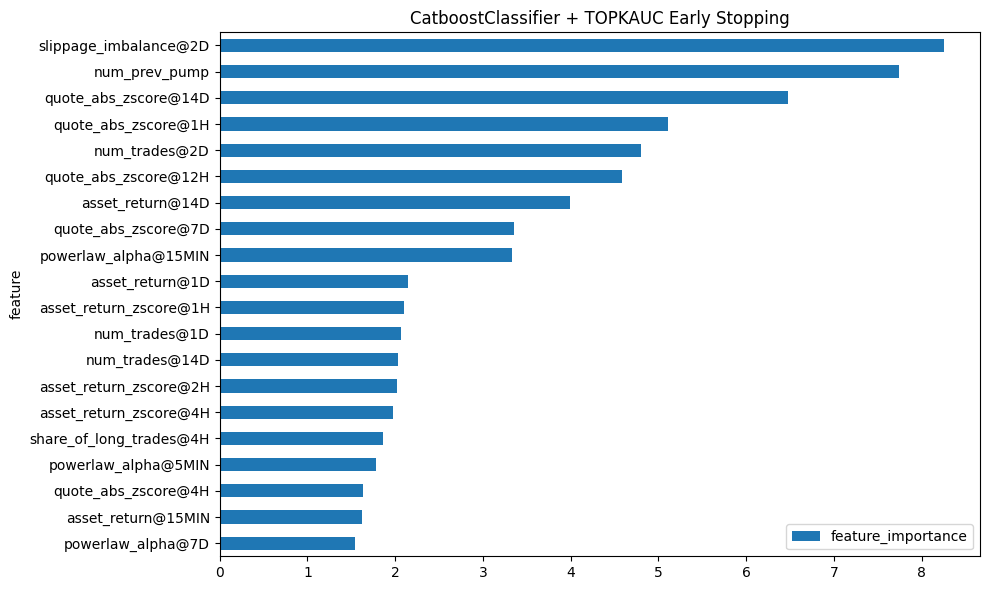

In [48]:
model = experiment_cb_topkauc_tuned.get_model()._model

df_fi = pd.DataFrame({
    "feature": model.feature_names_,
    "feature_importance": model.feature_importances_
})
df_fi = df_fi.set_index("feature").sort_values(by="feature_importance", ascending=True)

df_fi.tail(20).plot.barh(figsize=(10, 6))
plt.title("CatboostClassifier + TOPKAUC Early Stopping")
plt.tight_layout()
plt.savefig("images/feature_importances.png")

<h4>TOPK metric for all models</h4>

In [49]:
?calculate_topk

Signature:
calculate_topk(
    model: analysis.pipelines.BaseModel.ImplementsRank,
    dataset: analysis.utils.sample.Dataset,
    bins: Iterable[float],
) -> pandas.Series
Docstring:
:param bins: bins used to calculate topk
:return: pd.Series with topk values. Which measures the chance of predicting the actual pump given we take a portfolio
of size K
File:      ~/dev/pumps_and_dumps/src/analysis/utils/metrics.py
Type:      function

In [50]:
from tqdm import tqdm
from analysis.pipelines.BaseModel import BaseModel, ImplementsRank


experiments: List[Experiment] = [
    experiment_lr,
    experiment_lr_tuned,
    experiment_rf,
    experiment_rf_tuned,
    experiment_cb,
    experiment_cb_tuned,
    experiment_cb_smote,
    experiment_cb_smote_tuned,
    experiment_cb_ranker,
    experiment_cb_ranker_tuned,
    experiment_cb_topkauc_tuned
]

In [51]:
topk_vals: Dict[str, List[float]] = {}

for experiment in tqdm(experiments):
    name: str = experiment.get_experiment_name()
    sample: Sample = experiment.get_sample()
    model: ImplementsRank = experiment.get_model()
    vals: List[float] = calculate_topk(
        model=model, dataset=sample.get_dataset(DatasetType.TEST), bins=[1, 2, 3, 5, 10, 20, 30]
    )
    topk_vals[name] = vals


df_topk: pd.DataFrame = pd.DataFrame(topk_vals)

def highlight_max(s):
    is_max = s == s.max()
    return ['background-color: yellow' if v else '' for v in is_max]


styled = df_topk.T.style.apply(highlight_max, axis=0)
styled

100%|██████████| 11/11 [00:01<00:00,  7.36it/s]


,1,2,3,5,10,20,30
LogisticRegression,0.172414,0.206897,0.275862,0.379310,0.482759,0.672414,0.706897
LogisticRegression + Tuned,0.120690,0.172414,0.241379,0.362069,0.534483,0.706897,0.758621
RandomForestClassifier,0.120690,0.241379,0.310345,0.310345,0.379310,0.465517,0.620690
RandomForestClassifier + Tuned,0.172414,0.206897,0.258621,0.327586,0.482759,0.672414,0.775862
CatboostClassifier,0.103448,0.172414,0.241379,0.275862,0.379310,0.655172,0.741379
CatboostClassifier + Tuned,0.155172,0.258621,0.275862,0.293103,0.517241,0.655172,0.810345
CatboostClassifier + SMOTE,0.051724,0.137931,0.172414,0.224138,0.258621,0.344828,0.500000
CatboostClassifier + SMOTE + Tuned,0.051724,0.120690,0.189655,0.241379,0.344828,0.534483,0.620690
CatboostRanker,0.120690,0.155172,0.189655,0.241379,0.379310,0.534483,0.637931
CatboostRanker + Tuned,0.068966,0.155172,0.241379,0.396552,0.482759,0.551724,0.620690


In [52]:
print(df_topk.T.to_latex())

\begin{tabular}{lrrrrrrr}
\toprule
 & 1 & 2 & 3 & 5 & 10 & 20 & 30 \\
\midrule
LogisticRegression & 0.172414 & 0.206897 & 0.275862 & 0.379310 & 0.482759 & 0.672414 & 0.706897 \\
LogisticRegression + Tuned & 0.120690 & 0.172414 & 0.241379 & 0.362069 & 0.534483 & 0.706897 & 0.758621 \\
RandomForestClassifier & 0.120690 & 0.241379 & 0.310345 & 0.310345 & 0.379310 & 0.465517 & 0.620690 \\
RandomForestClassifier + Tuned & 0.172414 & 0.206897 & 0.258621 & 0.327586 & 0.482759 & 0.672414 & 0.775862 \\
CatboostClassifier & 0.103448 & 0.172414 & 0.241379 & 0.275862 & 0.379310 & 0.655172 & 0.741379 \\
CatboostClassifier + Tuned & 0.155172 & 0.258621 & 0.275862 & 0.293103 & 0.517241 & 0.655172 & 0.810345 \\
CatboostClassifier + SMOTE & 0.051724 & 0.137931 & 0.172414 & 0.224138 & 0.258621 & 0.344828 & 0.500000 \\
CatboostClassifier + SMOTE + Tuned & 0.051724 & 0.120690 & 0.189655 & 0.241379 & 0.344828 & 0.534483 & 0.620690 \\
CatboostRanker & 0.120690 & 0.155172 & 0.189655 & 0.241379 & 0.379310 & 0

In [53]:
cols = [col for col in df_topk.columns if col.endswith("Tuned")] + ["CatboostClassifier + TOPKAUC Early Stopping"]

In [54]:
def random_topk():
    df_all = sample.get_dataset(DatasetType.TEST).all_data()
    topks = []
    for k in [1, 2, 3, 5, 10, 20, 30]:
        p = k / df_all.groupby("pump_hash")["pump_hash"].count()
        topks.append(p.sum() / len(p))

    return topks


random_topk()

[np.float64(0.0034279887421742187),
 np.float64(0.006855977484348437),
 np.float64(0.010283966226522655),
 np.float64(0.017139943710871092),
 np.float64(0.034279887421742185),
 np.float64(0.06855977484348437),
 np.float64(0.10283966226522655)]

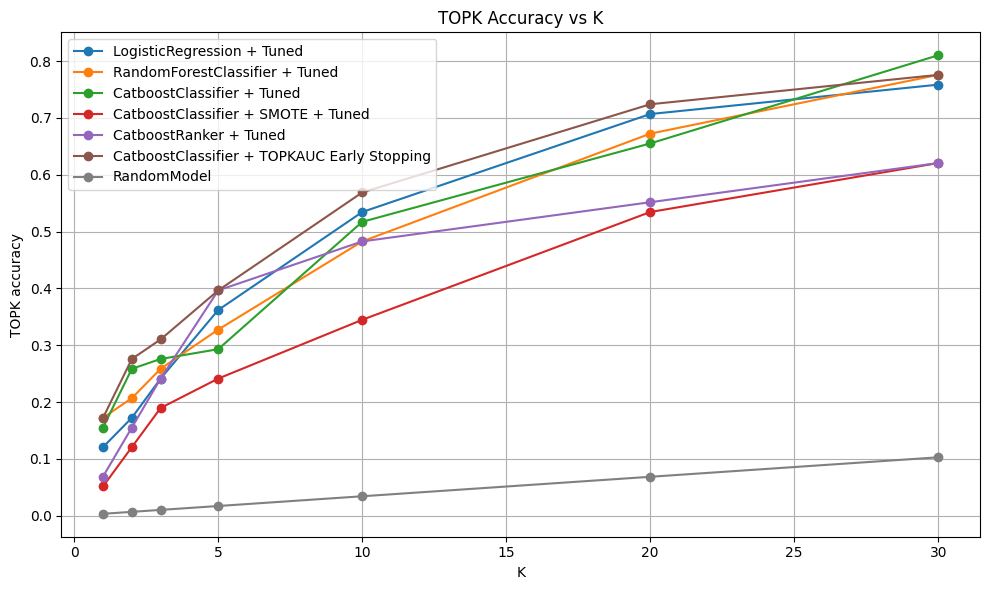

In [55]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot()
df_topk[cols].plot(ax=ax, marker="o")
plt.plot([1, 2, 3, 5, 10, 20, 30], random_topk(), color="grey", marker="o", label="RandomModel")
plt.legend()
plt.ylabel("TOPK accuracy")
plt.xlabel("K")
plt.title("TOPK Accuracy vs K")
plt.grid()
plt.tight_layout()
plt.savefig("images/topk_accuracy_test.png")

<h4>TOPK% for models</h4>

In [56]:
topkp_vals: Dict[str, List[float]] = {}

for experiment in tqdm(experiments):
    name: str = experiment.get_experiment_name()
    sample: Sample = experiment.get_sample()
    model: ImplementsRank = experiment.get_model()
    vals: List[float] = calculate_topk_percent(model=model, dataset=sample.get_dataset(DatasetType.TEST), bins=[0.01, 0.02, 0.05, 0.1, 0.2, 0.5])
    topkp_vals[name] = vals

df_topkp: pd.DataFrame = pd.DataFrame(topkp_vals)

styled = df_topkp.style.apply(highlight_max, axis=1)
styled

100%|██████████| 11/11 [00:01<00:00,  8.41it/s]


,LogisticRegression,LogisticRegression + Tuned,RandomForestClassifier,RandomForestClassifier + Tuned,CatboostClassifier,CatboostClassifier + Tuned,CatboostClassifier + SMOTE,CatboostClassifier + SMOTE + Tuned,CatboostRanker,CatboostRanker + Tuned,CatboostClassifier + TOPKAUC Early Stopping
0.010000,0.275862,0.275862,0.310345,0.258621,0.241379,0.275862,0.189655,0.206897,0.206897,0.275862,0.310345
0.020000,0.396552,0.396552,0.310345,0.396552,0.310345,0.344828,0.241379,0.258621,0.310345,0.413793,0.431034
0.050000,0.568966,0.603448,0.448276,0.568966,0.603448,0.620690,0.310345,0.431034,0.517241,0.517241,0.689655
0.100000,0.706897,0.758621,0.603448,0.775862,0.758621,0.793103,0.482759,0.620690,0.637931,0.620690,0.741379
0.200000,0.810345,0.862069,0.793103,0.931034,0.896552,0.879310,0.655172,0.758621,0.758621,0.775862,0.862069
0.500000,0.965517,0.965517,0.913793,0.982759,0.965517,0.965517,0.948276,0.931034,0.862069,0.896552,0.982759


In [57]:
print(df_topkp.T.to_latex())

\begin{tabular}{lrrrrrr}
\toprule
 & 0.010000 & 0.020000 & 0.050000 & 0.100000 & 0.200000 & 0.500000 \\
\midrule
LogisticRegression & 0.275862 & 0.396552 & 0.568966 & 0.706897 & 0.810345 & 0.965517 \\
LogisticRegression + Tuned & 0.275862 & 0.396552 & 0.603448 & 0.758621 & 0.862069 & 0.965517 \\
RandomForestClassifier & 0.310345 & 0.310345 & 0.448276 & 0.603448 & 0.793103 & 0.913793 \\
RandomForestClassifier + Tuned & 0.258621 & 0.396552 & 0.568966 & 0.775862 & 0.931034 & 0.982759 \\
CatboostClassifier & 0.241379 & 0.310345 & 0.603448 & 0.758621 & 0.896552 & 0.965517 \\
CatboostClassifier + Tuned & 0.275862 & 0.344828 & 0.620690 & 0.793103 & 0.879310 & 0.965517 \\
CatboostClassifier + SMOTE & 0.189655 & 0.241379 & 0.310345 & 0.482759 & 0.655172 & 0.948276 \\
CatboostClassifier + SMOTE + Tuned & 0.206897 & 0.258621 & 0.431034 & 0.620690 & 0.758621 & 0.931034 \\
CatboostRanker & 0.206897 & 0.310345 & 0.517241 & 0.637931 & 0.758621 & 0.862069 \\
CatboostRanker + Tuned & 0.275862 & 0.41379

<h4>TOPK% curves for all models</h4>

In [58]:
topkp_vals: Dict[str, List[float]] = {}
auc_scores: List[float] = []

for experiment in tqdm(experiments):
    name: str = experiment.get_experiment_name()
    sample: Sample = experiment.get_sample()
    model: ImplementsRank = experiment.get_model()
    dataset: Dataset = sample.get_dataset(DatasetType.TEST)
    vals: List[float] = calculate_topk_percent(model=model, dataset=dataset, bins=np.arange(0, 1.01, 0.01))
    topkp_vals[name] = vals
    auc_scores.append(
        calculate_topk_percent_auc(model=model, dataset=dataset)
    )

df_topkp = pd.DataFrame(topkp_vals)

100%|██████████| 11/11 [00:12<00:00,  1.18s/it]


In [59]:
df_topkp

,LogisticRegression,LogisticRegression + Tuned,RandomForestClassifier,RandomForestClassifier + Tuned,CatboostClassifier,CatboostClassifier + Tuned,CatboostClassifier + SMOTE,CatboostClassifier + SMOTE + Tuned,CatboostRanker,CatboostRanker + Tuned,CatboostClassifier + TOPKAUC Early Stopping
0.00,0.172414,0.120690,0.120690,0.172414,0.103448,0.155172,0.051724,0.051724,0.120690,0.068966,0.172414
0.01,0.275862,0.275862,0.310345,0.258621,0.241379,0.275862,0.189655,0.206897,0.206897,0.275862,0.310345
0.02,0.396552,0.396552,0.310345,0.396552,0.310345,0.344828,0.241379,0.258621,0.310345,0.413793,0.431034
0.03,0.465517,0.534483,0.362069,0.465517,0.379310,0.500000,0.258621,0.310345,0.362069,0.482759,0.551724
0.04,0.568966,0.568966,0.413793,0.517241,0.448276,0.551724,0.293103,0.396552,0.448276,0.500000,0.620690
...,...,...,...,...,...,...,...,...,...,...,...
0.96,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.982759,1.000000,1.000000
0.97,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.982759,1.000000,1.000000
0.98,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.982759,1.000000,1.000000
0.99,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.982759,1.000000,1.000000


In [60]:
legends = [f"{experiment.experiment_name} - {round(score, 3)}" for experiment, score in zip(experiments, auc_scores) if experiment.experiment_name in cols]
X = np.arange(0, 1.01, 0.01)

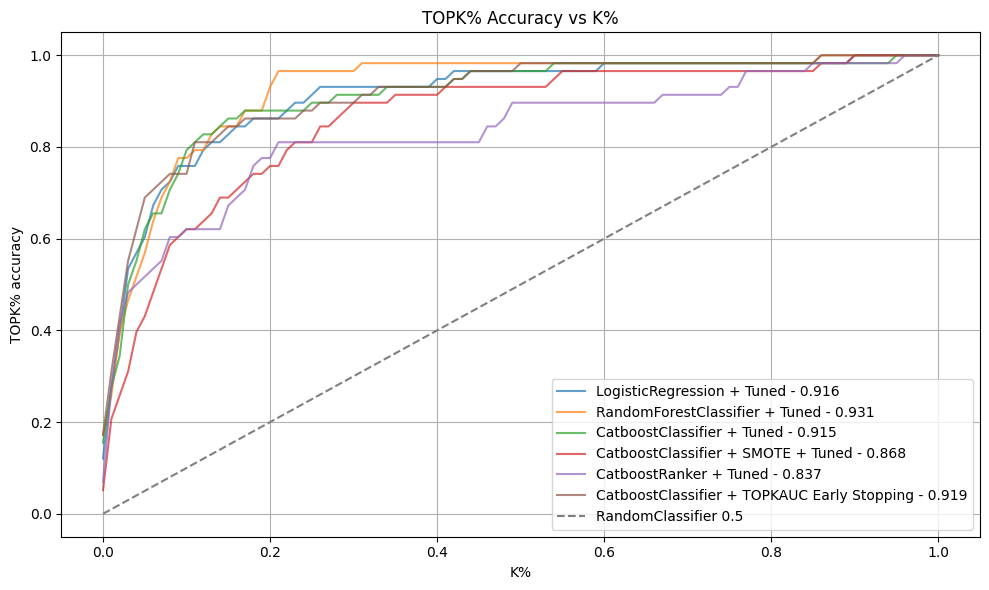

In [61]:
df_topkp[cols].plot(figsize=(10, 6), alpha=0.7)
plt.plot(X, X, linestyle="--", color="grey", label="RandomClassifier")
plt.legend(legends + ["RandomClassifier 0.5"])
plt.xlabel("K%")
plt.ylabel("TOPK% accuracy")
plt.title("TOPK% Accuracy vs K%")
plt.grid()
plt.tight_layout()
plt.savefig("images/topkp_auc_test.png")

<h4>Classification metrics on TEST</h4>
<p>Alongside ranking metrics, we also report PR-AUC, F1, and balanced accuracy. For F1/balanced accuracy we use the <code>top1_per_cross_section</code> decision rule.</p>

In [62]:
from analysis.utils.metrics import calculate_f1, calculate_pr_auc, calculate_balanced_accuracy

In [63]:
classification_rows: List[Dict[str, float | str]] = []

for experiment in tqdm(experiments):
    name: str = experiment.get_experiment_name()
    sample: Sample = experiment.get_sample()
    model: ImplementsRank = experiment.get_model()
    dataset: Dataset = sample.get_dataset(DatasetType.TEST)

    classification_rows.append({
        "Model": name,
        "PR-AUC": calculate_pr_auc(model=model, dataset=dataset),
        "F1 (top1/cross-section)": calculate_f1(model=model, dataset=dataset, decision_rule="top1_per_cross_section"),
        "Balanced Accuracy (top1/cross-section)": calculate_balanced_accuracy(model=model, dataset=dataset, decision_rule="top1_per_cross_section"),
    })

df_classification_metrics: pd.DataFrame = pd.DataFrame(classification_rows).set_index("Model")
styled = df_classification_metrics.style.apply(highlight_max, axis=0).format("{:.4f}")
styled

100%|██████████| 11/11 [00:02<00:00,  3.79it/s]


,PR-AUC,F1 (top1/cross-section),Balanced Accuracy (top1/cross-section)
Model,,,
LogisticRegression,0.0869,0.1724,0.5848
LogisticRegression + Tuned,0.0611,0.1207,0.5588
RandomForestClassifier,0.0884,0.1379,0.5675
RandomForestClassifier + Tuned,0.0658,0.1724,0.5848
CatboostClassifier,0.0554,0.1034,0.5502
CatboostClassifier + Tuned,0.1020,0.1552,0.5761
CatboostClassifier + SMOTE,0.0319,0.0517,0.5242
CatboostClassifier + SMOTE + Tuned,0.0354,0.0517,0.5242
CatboostRanker,0.0475,0.1207,0.5588


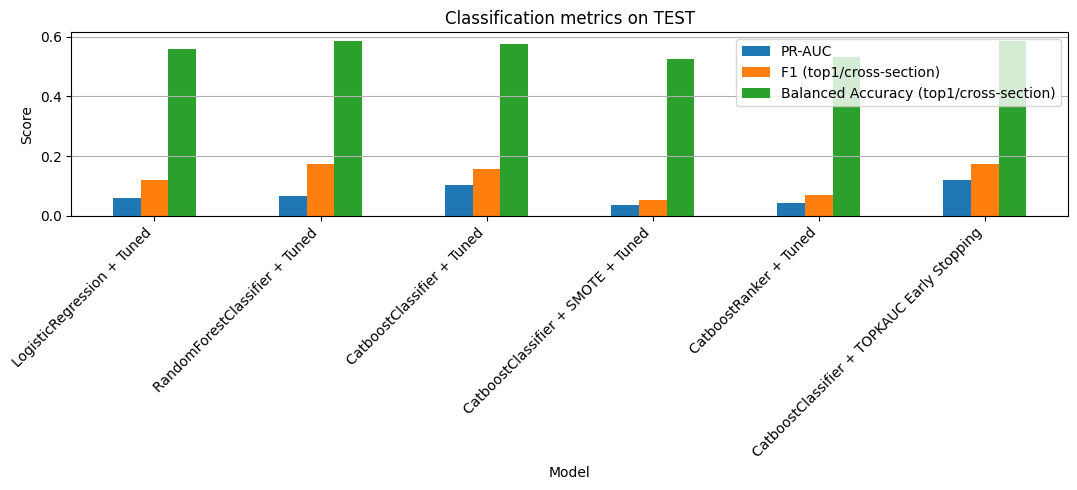

In [64]:
plot_cols = [c for c in cols if c in df_classification_metrics.index]

ax = df_classification_metrics.loc[plot_cols].plot(kind="bar", figsize=(11, 5))
ax.set_title("Classification metrics on TEST")
ax.set_ylabel("Score")
ax.set_xlabel("Model")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.tight_layout()
plt.savefig("images/classification_metrics_test.png")

<h4>Test Sample PnL</h4>

In [65]:
def get_equity_curve_for_experiment(experiment: Experiment, portfolio_size: int = 5) -> pd.Series:
    sample: Sample = experiment.get_sample()
    manager = TOPKPortfolio(model=experiment.get_model(), portfolio_size=portfolio_size)
    dataset: Dataset = sample.get_dataset(ds_type=DatasetType.TEST)
    results: List[Dict[str, Any]] = []

    for pump in tqdm(sorted(dataset.get_pumps()), desc=f"Computing equity curve for {experiment.get_experiment_name()} amd K={portfolio_size}"):
        stat: PortfolioStats = manager.evaluate_for_pump(dataset=dataset, pump=pump)
        results.append({"time": pump.time, "portfolio_return": stat.pnl})

    return pd.DataFrame(results).set_index("time")

In [66]:
equity_curves: Dict[str, pd.Series] = {}

for experiment in experiments:
    equity_curves[experiment.experiment_name] = get_equity_curve_for_experiment(experiment=experiment)

Computing equity curve for LogisticRegression amd K=5:  71%|███████   | 41/58 [00:12<00:01,  9.47it/s]2026-03-09 15:43:15,277 | INFO | root | No data to get prices for DLT-BTC
2026-03-09 15:43:15,339 | INFO | root | No data to get prices for DLT-BTC
Computing equity curve for LogisticRegression amd K=5:  86%|████████▌ | 50/58 [00:13<00:00,  9.75it/s]2026-03-09 15:43:16,156 | INFO | root | No data to get prices for EVX-BTC
Computing equity curve for LogisticRegression amd K=5:  88%|████████▊ | 51/58 [00:13<00:00,  9.70it/s]2026-03-09 15:43:16,258 | INFO | root | No data to get prices for EVX-BTC
2026-03-09 15:43:16,352 | INFO | root | No data to get prices for EVX-BTC
Computing equity curve for LogisticRegression amd K=5:  91%|█████████▏| 53/58 [00:13<00:00,  9.87it/s]2026-03-09 15:43:16,501 | INFO | root | No data to get prices for LUNA-BTC
Computing equity curve for LogisticRegression amd K=5:  98%|█████████▊| 57/58 [00:14<00:00, 10.06it/s]2026-03-09 15:43:16,784 | INFO | root | No da

In [67]:
df_curves = pd.concat(equity_curves.values(), axis=1)
df_curves.columns = equity_curves.keys()
df_curves.head()

,LogisticRegression,LogisticRegression + Tuned,RandomForestClassifier,RandomForestClassifier + Tuned,CatboostClassifier,CatboostClassifier + Tuned,CatboostClassifier + SMOTE,CatboostClassifier + SMOTE + Tuned,CatboostRanker,CatboostRanker + Tuned,CatboostClassifier + TOPKAUC Early Stopping
time,,,,,,,,,,,
2021-05-09 17:00:02,-0.004000,-0.000656,0.004024,0.000080,0.003272,0.000080,0.002257,0.004608,0.010430,0.010718,0.004336
2021-05-16 17:00:01,0.021979,0.010802,-0.002659,0.000829,0.005849,0.006049,0.000957,0.006172,0.003346,0.007360,0.010612
2021-05-26 17:00:02,0.067240,0.058884,0.061038,0.061038,0.061038,0.062633,0.007765,0.008483,0.061038,0.059765,0.064087
2021-05-30 17:00:02,0.097780,0.094486,0.092770,0.023405,0.021982,0.019578,0.018544,0.018982,0.102894,0.102171,0.098773
2021-06-05 18:00:13,0.044696,0.041934,0.048228,0.002656,-0.000276,0.002656,-0.002921,-0.003200,0.052900,0.047875,0.002242


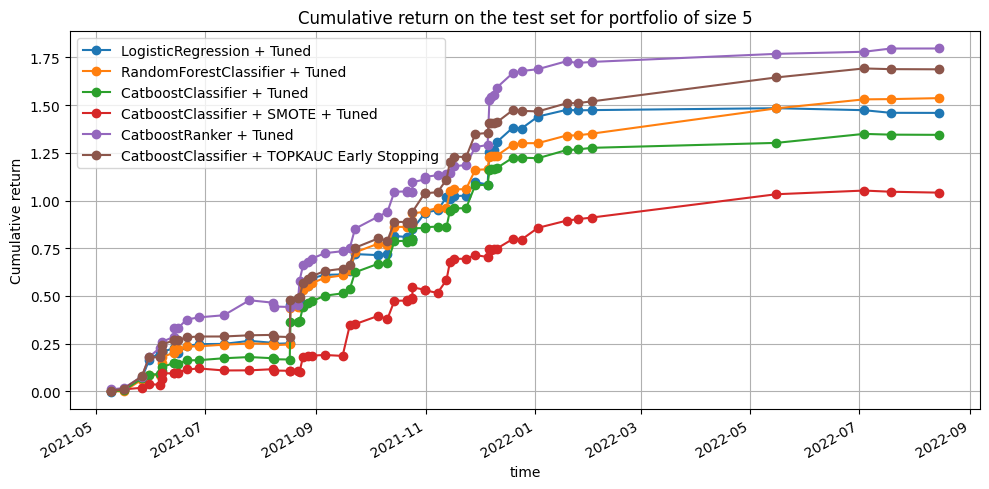

In [68]:
df_curves[cols].cumsum().plot(figsize=(10, 5), marker="o")
plt.title("Cumulative return on the test set for portfolio of size 5")
plt.ylabel("Cumulative return")

plt.grid()
plt.tight_layout()
plt.savefig("images/portfolios_test.png")

<h4>Portfolio performance for TOPKAUC ES Model</h4>

In [69]:
curves: Dict[int, pd.Series] = {}

for k in [1, 2, 5, 10, 20, 30]:
    curves[k] = get_equity_curve_for_experiment(experiment=experiment_cb_topkauc_tuned, portfolio_size=k)

Computing equity curve for CatboostClassifier + TOPKAUC Early Stopping amd K=1: 100%|██████████| 58/58 [00:10<00:00,  5.75it/s]
Computing equity curve for CatboostClassifier + TOPKAUC Early Stopping amd K=2: 100%|██████████| 58/58 [00:10<00:00,  5.59it/s]
Computing equity curve for CatboostClassifier + TOPKAUC Early Stopping amd K=5: 100%|██████████| 58/58 [00:14<00:00,  4.11it/s]
Computing equity curve for CatboostClassifier + TOPKAUC Early Stopping amd K=10: 100%|██████████| 58/58 [00:20<00:00,  2.84it/s]
Computing equity curve for CatboostClassifier + TOPKAUC Early Stopping amd K=20: 100%|██████████| 58/58 [00:32<00:00,  1.79it/s]
Computing equity curve for CatboostClassifier + TOPKAUC Early Stopping amd K=30: 100%|██████████| 58/58 [00:42<00:00,  1.36it/s]


In [70]:
df = pd.concat(curves, axis=1)
df.columns = [1, 2, 5, 10, 20, 30]
df.index = df.index.date
# Sum returns for days with multiple pumps
df = df.groupby(df.index).sum()

full = pd.date_range(df.index.min(), df.index.max(), freq="D")
df_full = df.reindex(full, fill_value=0)

annualized_returns = df_full.mean() * 365
annualized_std = df_full.std() * np.sqrt(365)
mean_trade_return = df.mean()
sharpe_ratio = annualized_returns / annualized_std

df_results = pd.DataFrame({
    "trading avg return": mean_trade_return,
    "annualized return": annualized_returns,
    "annualized volatility": annualized_std,
    "Sharpe ratio": sharpe_ratio
})

df_results

,trading avg return,annualized return,annualized volatility,Sharpe ratio
1,0.060533,2.433735,0.837876,2.904648
2,0.055430,2.228562,0.671317,3.319687
5,0.033082,1.330085,0.339777,3.914584
10,0.022875,0.919705,0.211108,4.356553
20,0.014313,0.575466,0.139890,4.113698
30,0.010412,0.418597,0.109307,3.829547


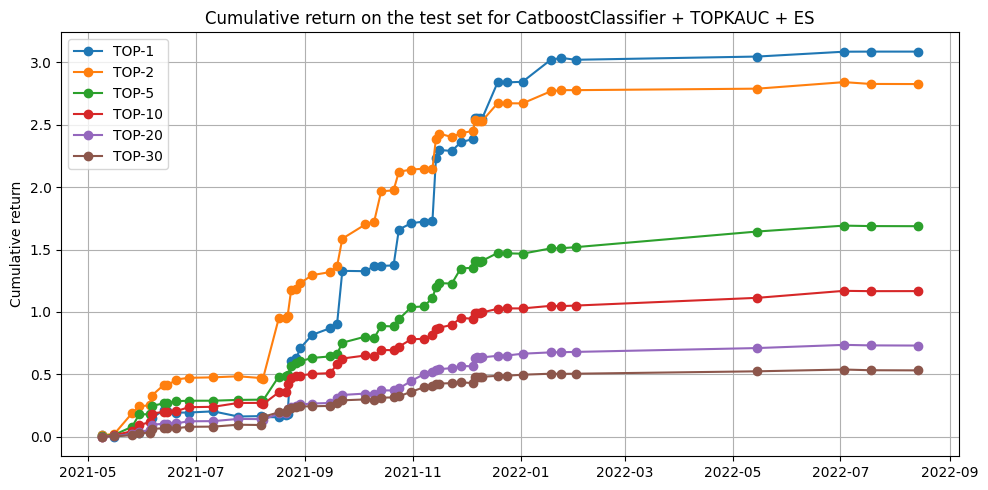

In [71]:
ax = df.cumsum().plot(figsize=(10, 5), marker="o")
ax.legend(["TOP-1", "TOP-2", "TOP-5", "TOP-10", "TOP-20", "TOP-30"])

plt.title("Cumulative return on the test set for CatboostClassifier + TOPKAUC + ES")
plt.ylabel("Cumulative return")
plt.grid()
plt.tight_layout()
plt.savefig("images/portfolios_test.png", dpi=600)

<h4>Execution-aware PnL with regression price impact</h4>
<p>We fit a side-aware price impact regression for each traded asset using the previous 14 days of trades and recompute strategy PnL for different order notionals.</p>

In [72]:
from datetime import timedelta

from analysis.portfolio.TOPKPortfolio import evaluate_topk_pnl_for_quantities

In [74]:
impact_quantities_quote = [0.01, 0.02, 0.05, 0.1, 0.2]

dataset_test = experiment_cb_topkauc_tuned.get_sample().get_dataset(DatasetType.TEST)

df_pnl_by_quantity = evaluate_topk_pnl_for_quantities(
    model=experiment_cb_topkauc_tuned.get_model(),
    dataset=dataset_test,
    portfolio_size=5,
    quantities_quote=impact_quantities_quote,
    buy_before=timedelta(minutes=15),
    sell_after=timedelta(minutes=1),
    impact_lookback_days=14,
    impact_liquidity_quantile=0.9,
)

df_pnl_by_quantity

,quantity_quote,overall_pnl,mean_pnl,mean_fill_ratio
0,0.01,1.543940,0.026620,0.938233
1,0.02,1.007354,0.017368,0.702197
2,0.05,0.419223,0.007228,0.314077
3,0.10,0.209746,0.003616,0.157928
4,0.20,0.104873,0.001808,0.078964


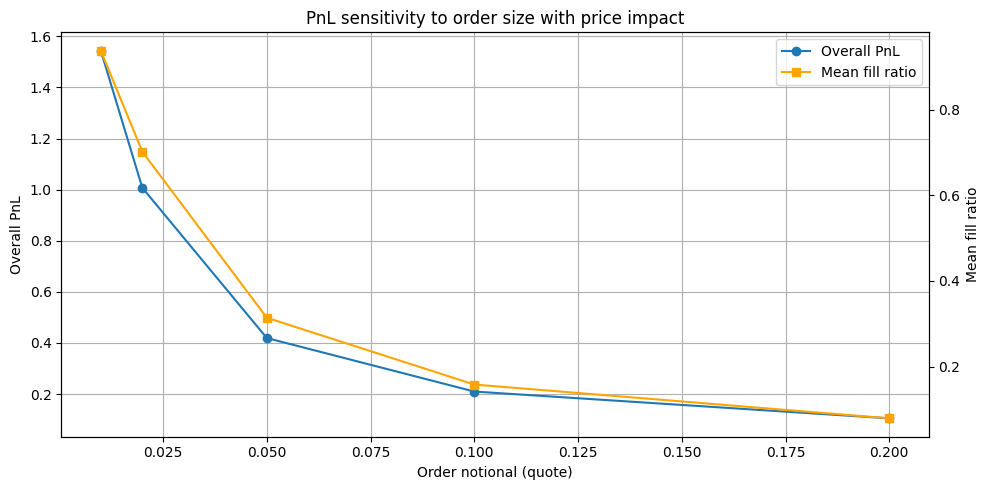

In [75]:
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(df_pnl_by_quantity["quantity_quote"], df_pnl_by_quantity["overall_pnl"], marker="o", label="Overall PnL")
ax1.set_xlabel("Order notional (quote)")
ax1.set_ylabel("Overall PnL")
ax1.grid(True)

ax2 = ax1.twinx()
ax2.plot(df_pnl_by_quantity["quantity_quote"], df_pnl_by_quantity["mean_fill_ratio"], color="orange", marker="s", label="Mean fill ratio")
ax2.set_ylabel("Mean fill ratio")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")
plt.title("PnL sensitivity to order size with price impact")
plt.tight_layout()
plt.savefig("images/pnl_vs_quantity_with_impact.png")

<h4>Robustness checks: train on subset of cross-sections</h4>
<p>We repeatedly train the same pipeline on random subsets of <code>TRAIN</code> cross-sections, evaluate on the fixed <code>TEST</code> split, and collect a distribution of ranking metrics.</p>

In [76]:
from pathlib import Path

from analysis.pipelines.CatboostClassifierTOPKAUC.pipe import CatboostClassifierTOPKAUCPipeline
from analysis.robust.robustness import (
    run_cross_section_subset_robustness,
    summarise_robustness_distribution,
)

In [77]:
ROBUSTNESS_OUTPUT: Path = Path("analysis_outputs/robustness/catboost_topkauc_subset_runs.csv")

df_robustness: pd.DataFrame = run_cross_section_subset_robustness(
    pipeline_factory=CatboostClassifierTOPKAUCPipeline,
    subset_fraction=0.7,
    n_runs=25,
    tuned=True,  # set to False if tuned studies are not available locally
    topk_bins=[0.01, 0.02, 0.05, 0.1, 0.2],
    base_seed=42,
    output_path=ROBUSTNESS_OUTPUT,
)

df_robustness.head()

2026-03-09 15:50:05,498 | INFO | root | Using cached preprocessed datasets for CatboostClassifierTOPKAUCPipeline
/home/borokoko/.cache/pypoetry/virtualenvs/pumps-and-dumps-tlIXlxVv-py3.13/lib/python3.13/site-packages/catboost/core.py:2627: UserWarning: Failed to import numba for optimizing custom metrics and objectives
  _check_train_params(params)


0:	learn: 0.7568239	test: 0.8295946	best: 0.8295946 (0)	total: 75.7ms	remaining: 1m 15s
10:	learn: 0.8719811	test: 0.8855405	best: 0.8943919 (7)	total: 829ms	remaining: 1m 14s
20:	learn: 0.8948428	test: 0.9025000	best: 0.9025000 (20)	total: 1.83s	remaining: 1m 25s
30:	learn: 0.9068239	test: 0.9067568	best: 0.9076351 (28)	total: 2.69s	remaining: 1m 24s
40:	learn: 0.9167925	test: 0.9015541	best: 0.9076351 (28)	total: 3.47s	remaining: 1m 21s
50:	learn: 0.9200000	test: 0.9056081	best: 0.9076351 (28)	total: 4.21s	remaining: 1m 18s
60:	learn: 0.9279245	test: 0.9016892	best: 0.9076351 (28)	total: 4.93s	remaining: 1m 15s
70:	learn: 0.9322327	test: 0.9050676	best: 0.9076351 (28)	total: 5.66s	remaining: 1m 14s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.9076351351
bestIteration = 28

Shrink model to first 29 iterations.


/home/borokoko/.cache/pypoetry/virtualenvs/pumps-and-dumps-tlIXlxVv-py3.13/lib/python3.13/site-packages/catboost/core.py:2627: UserWarning: Failed to import numba for optimizing custom metrics and objectives
  _check_train_params(params)


0:	learn: 0.7658176	test: 0.8304054	best: 0.8304054 (0)	total: 72.3ms	remaining: 1m 12s
10:	learn: 0.8771069	test: 0.9000000	best: 0.9000000 (10)	total: 850ms	remaining: 1m 16s
20:	learn: 0.8946855	test: 0.8968919	best: 0.9048649 (13)	total: 1.68s	remaining: 1m 18s
30:	learn: 0.9037736	test: 0.8993919	best: 0.9048649 (13)	total: 2.45s	remaining: 1m 16s
40:	learn: 0.9101887	test: 0.9021622	best: 0.9048649 (13)	total: 3.17s	remaining: 1m 14s
50:	learn: 0.9200629	test: 0.9048649	best: 0.9060135 (46)	total: 3.91s	remaining: 1m 12s
60:	learn: 0.9243082	test: 0.9066892	best: 0.9084459 (54)	total: 4.7s	remaining: 1m 12s
70:	learn: 0.9297170	test: 0.9064865	best: 0.9095946 (68)	total: 5.53s	remaining: 1m 12s
80:	learn: 0.9345597	test: 0.9087162	best: 0.9104730 (79)	total: 6.35s	remaining: 1m 12s
90:	learn: 0.9381132	test: 0.9072973	best: 0.9104730 (79)	total: 7.09s	remaining: 1m 10s
100:	learn: 0.9425472	test: 0.9056757	best: 0.9104730 (79)	total: 7.82s	remaining: 1m 9s
110:	learn: 0.9474528	t

/home/borokoko/.cache/pypoetry/virtualenvs/pumps-and-dumps-tlIXlxVv-py3.13/lib/python3.13/site-packages/catboost/core.py:2627: UserWarning: Failed to import numba for optimizing custom metrics and objectives
  _check_train_params(params)


...

/home/borokoko/.cache/pypoetry/virtualenvs/pumps-and-dumps-tlIXlxVv-py3.13/lib/python3.13/site-packages/catboost/core.py:2627: UserWarning: Failed to import numba for optimizing custom metrics and objectives
  _check_train_params(params)


0:	learn: 0.7529560	test: 0.8304054	best: 0.8304054 (0)	total: 75.4ms	remaining: 1m 15s
10:	learn: 0.8857862	test: 0.8881757	best: 0.8881757 (10)	total: 1.08s	remaining: 1m 37s
20:	learn: 0.8943082	test: 0.8927027	best: 0.8927027 (20)	total: 1.83s	remaining: 1m 25s
30:	learn: 0.9026730	test: 0.8945270	best: 0.8959459 (24)	total: 2.57s	remaining: 1m 20s
40:	learn: 0.9082075	test: 0.9007432	best: 0.9025000 (38)	total: 3.31s	remaining: 1m 17s
50:	learn: 0.9126101	test: 0.9038514	best: 0.9046622 (49)	total: 4.15s	remaining: 1m 17s
60:	learn: 0.9172327	test: 0.9012838	best: 0.9047973 (58)	total: 4.98s	remaining: 1m 16s
70:	learn: 0.9204403	test: 0.9046622	best: 0.9047973 (58)	total: 5.8s	remaining: 1m 15s
80:	learn: 0.9268239	test: 0.9035135	best: 0.9047973 (58)	total: 6.65s	remaining: 1m 15s
90:	learn: 0.9328931	test: 0.9060135	best: 0.9060135 (90)	total: 7.48s	remaining: 1m 14s
100:	learn: 0.9362264	test: 0.9088514	best: 0.9088514 (100)	total: 8.21s	remaining: 1m 13s
110:	learn: 0.9412264

/home/borokoko/.cache/pypoetry/virtualenvs/pumps-and-dumps-tlIXlxVv-py3.13/lib/python3.13/site-packages/catboost/core.py:2627: UserWarning: Failed to import numba for optimizing custom metrics and objectives
  _check_train_params(params)


0:	learn: 0.7522956	test: 0.8317568	best: 0.8317568 (0)	total: 78.5ms	remaining: 1m 18s
10:	learn: 0.8796541	test: 0.8956081	best: 0.8985811 (7)	total: 967ms	remaining: 1m 26s
20:	learn: 0.8957233	test: 0.8895946	best: 0.8985811 (7)	total: 1.73s	remaining: 1m 20s
30:	learn: 0.9075786	test: 0.8933784	best: 0.8985811 (7)	total: 2.48s	remaining: 1m 17s
40:	learn: 0.9143082	test: 0.8992568	best: 0.8993243 (38)	total: 3.22s	remaining: 1m 15s
50:	learn: 0.9206918	test: 0.9058108	best: 0.9058108 (50)	total: 4s	remaining: 1m 14s
60:	learn: 0.9262264	test: 0.9075676	best: 0.9075676 (60)	total: 4.76s	remaining: 1m 13s
70:	learn: 0.9311635	test: 0.9033108	best: 0.9077703 (61)	total: 5.51s	remaining: 1m 12s
80:	learn: 0.9357547	test: 0.8979730	best: 0.9077703 (61)	total: 6.46s	remaining: 1m 13s
90:	learn: 0.9389623	test: 0.9009459	best: 0.9077703 (61)	total: 7.27s	remaining: 1m 12s
100:	learn: 0.9441195	test: 0.8959459	best: 0.9077703 (61)	total: 8.08s	remaining: 1m 11s
110:	learn: 0.9497799	test:

,run_idx,seed,subset_fraction,train_rows,train_cross_sections,test_rows,test_cross_sections,topk_percent_auc,topk_percent@0.01,topk_percent@0.02,topk_percent@0.05,topk_percent@0.1,topk_percent@0.2
0,0,42,0.7,24668,159,16960,58,0.931379,0.327586,0.431034,0.637931,0.775862,0.896552
1,1,43,0.7,24613,159,16960,58,0.919569,0.293103,0.413793,0.672414,0.758621,0.862069
2,2,44,0.7,24651,159,16960,58,0.913276,0.310345,0.448276,0.603448,0.741379,0.879310
3,3,45,0.7,24876,159,16960,58,0.920000,0.275862,0.413793,0.603448,0.741379,0.862069
4,4,46,0.7,24536,159,16960,58,0.914310,0.310345,0.413793,0.620690,0.758621,0.896552


In [ ]:
robustness_summary: pd.DataFrame = summarise_robustness_distribution(
    results=df_robustness,
    metric_cols=[
        "topk_percent_auc",
        "topk_percent@0.01",
        "topk_percent@0.02",
        "topk_percent@0.05",
        "topk_percent@0.1",
        "topk_percent@0.2",
    ],
)

robustness_summary

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df_robustness["topk_percent_auc"].hist(ax=axes[0], bins=12, alpha=0.85)
axes[0].axvline(df_robustness["topk_percent_auc"].mean(), color="red", linestyle="--", label="Mean")
axes[0].set_title("Distribution of TOPK% AUC")
axes[0].set_xlabel("TOPK% AUC")
axes[0].set_ylabel("Count")
axes[0].legend()

metric_cols = ["topk_percent@0.01", "topk_percent@0.02", "topk_percent@0.05", "topk_percent@0.1", "topk_percent@0.2"]
df_robustness[metric_cols].boxplot(ax=axes[1])
axes[1].set_title("Distribution of TOPK% metrics")
axes[1].set_ylabel("Score")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("images/robustness_metrics_distribution.png")

<h4>Statistical significance: bootstrap CIs and paired hypothesis test</h4>
<p>Below we quantify uncertainty (95% confidence intervals) and test whether performance differences are statistically meaningful.</p>

In [ ]:
from analysis.utils.sample import DatasetType
from analysis.robust.significance import (
    score_dataset,
    bootstrap_topk_ci,
    bootstrap_topk_percent_ci,
    bootstrap_topk_percent_auc_ci,
    paired_bootstrap_topk_percent_auc_test,
)

In [ ]:
# Compare the best model against a strong baseline
exp_a = experiment_cb_topkauc_tuned
exp_b = experiment_cb_tuned

scored_a = score_dataset(
    model=exp_a.get_model(),
    dataset=exp_a.get_sample().get_dataset(DatasetType.TEST),
)
scored_b = score_dataset(
    model=exp_b.get_model(),
    dataset=exp_b.get_sample().get_dataset(DatasetType.TEST),
)

ci_auc_a = bootstrap_topk_percent_auc_ci(scored_df=scored_a, n_bootstrap=1000, alpha=0.05, random_state=42)
ci_auc_b = bootstrap_topk_percent_auc_ci(scored_df=scored_b, n_bootstrap=1000, alpha=0.05, random_state=42)

df_auc_ci = pd.DataFrame([
    {"model": exp_a.get_experiment_name(), **ci_auc_a.to_dict()},
    {"model": exp_b.get_experiment_name(), **ci_auc_b.to_dict()},
]).set_index("model")

df_auc_ci[["point_estimate", "ci_lower", "ci_upper"]]

In [ ]:
topk_bins = [1, 2, 3, 5, 10, 20, 30]
topkp_bins = [0.01, 0.02, 0.05, 0.1, 0.2]

df_topk_ci = bootstrap_topk_ci(
    scored_df=scored_a,
    bins=topk_bins,
    n_bootstrap=1000,
    alpha=0.05,
    random_state=42,
)

df_topkp_ci = bootstrap_topk_percent_ci(
    scored_df=scored_a,
    bins=topkp_bins,
    n_bootstrap=1000,
    alpha=0.05,
    random_state=42,
)

df_topk_ci

In [ ]:
paired_test = paired_bootstrap_topk_percent_auc_test(
    scored_df_a=scored_a,
    scored_df_b=scored_b,
    n_bootstrap=2000,
    alpha=0.05,
    random_state=42,
    alternative="greater",
)

pd.Series(paired_test.to_dict())

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

x = np.arange(len(df_topk_ci.index))
y = df_topk_ci["point_estimate"].to_numpy()
yerr = np.vstack([
    y - df_topk_ci["ci_lower"].to_numpy(),
    df_topk_ci["ci_upper"].to_numpy() - y,
])
axes[0].errorbar(x, y, yerr=yerr, fmt="o-", capsize=4)
axes[0].set_xticks(x)
axes[0].set_xticklabels(df_topk_ci.index)
axes[0].set_title("Top@K with 95% CI")
axes[0].set_xlabel("K")
axes[0].set_ylabel("Top@K")
axes[0].grid(True)

x2 = np.arange(len(df_topkp_ci.index))
y2 = df_topkp_ci["point_estimate"].to_numpy()
yerr2 = np.vstack([
    y2 - df_topkp_ci["ci_lower"].to_numpy(),
    df_topkp_ci["ci_upper"].to_numpy() - y2,
])
axes[1].errorbar(x2, y2, yerr=yerr2, fmt="o-", capsize=4)
axes[1].set_xticks(x2)
axes[1].set_xticklabels(df_topkp_ci.index)
axes[1].set_title("Top@K% with 95% CI")
axes[1].set_xlabel("K%")
axes[1].set_ylabel("Top@K%")
axes[1].grid(True)

plt.tight_layout()
plt.savefig("images/significance_bootstrap_ci.png")